# Adiabatic Rapid Passage

This example covers an example with both laser frequency and amplitude modulation: rapid adiabatic passage.  It reproduces Fig. 2 from T. Lu, X. Miao, and H. Metcalf, “Bloch theorem on the Bloch sphere” *Physical Review A* **71**, 061405(R) (2005), http://dx.doi.org/10.1103/PhysRevA.71.061405

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylcp
from pylcp.integration_tools_gpu import solve_ivp_dense
import jax.numpy as jnp

### Code the basic Hamiltonian

The Hamiltonian is a simple two-state Hamiltonian.  Here, we code up a method to return the time-dependent Hamiltonian matrix to evolve it with the Schrodinger equation.  We take the modulation to be the same as in Lu, *et. al.*, above: $\Omega(t) = \Omega_0\sin(\omega_m t)$ and $\Delta=\Delta_0\cos(\omega_m t)$.

In [2]:
def H(t, Delta0, Omega0, omegam):
    Delta = Delta0*np.cos(omegam*t)
    Omega = Omega0*np.sin(omegam*t)
    
    return 1/2*np.array([[Delta, Omega], [Omega, -Delta]])

### Define the problem in `pylcp`

Unlike the above Hamiltonian, which is clearly time dependent, the only time dependence available to us in `pylcp` is through the fields.  First, we need to remember for the amplitude modulation that $I/I_{\rm sat} = 2\Omega^2/\Gamma^ = 2[\Omega_0\sin(\omega_m t)]^2/\Gamma^2$.  Second, we need to frequency modulate the laser beams.  Remember that if the lasers have a temporal phase $\phi$, the frequency is $\omega = \frac{d\phi}{dt}$.  Thus, if the detuning $\Delta(t)$ is specified, then $\phi = \int \Delta (t)\ dt$.  `pylcp` contains a built-in integrator in order to convert the detuning to a phase, but it might not always be reliable.  So you can also reproduce the detuning by modulating the phase $\phi$.  To reproduce the $\Delta(t) = \Delta_0\cos(\omega_m t)$, we need $\phi = \Delta_0/\omega_m\sin(\omega_m t)$.  

In [3]:
def return_lasers(Delta0, Omega0, omegam):
    laserBeams = pylcp.laserBeams([
        {'kvec':np.array([1., 0., 0.]),
         'pol':np.array([0., 0., 1.]),
         'pol_coord':'cartesian',
         'delta': 0.,
         'phase': lambda t: Delta0/omegam * jnp.sin(omegam*t),
         's': lambda R, t: 2*(Omega0*jnp.sin(omegam*t))**2
        }])
    
    return laserBeams

magField = lambda R: np.zeros(R.shape)

# Now define the extremely simple Hamiltonian:
Hg = np.array([[0.]])
mugq = np.array([[[0.]], [[0.]], [[0.]]])
He = np.array([[0.]])
mueq = np.array([[[0.]], [[0.]], [[0.]]])
dijq = np.array([[[0.]], [[1.]], [[0.]]])

gamma = 1.

hamiltonian = pylcp.hamiltonian(Hg, He, mugq, mueq, dijq, gamma=gamma)
hamiltonian.print_structure()

[[((<g|H_0|g> 1x1), (<g|mu_q|g> 1x1)) (<g|d_q|e> 1x1)]
 [(<e|d_q|g> 1x1) ((<e|H_0|e> 1x1), (<e|mu_q|e> 1x1))]]


### Evolve a single state

We solve with both the Schrodinger Equation and the OBEs.  We can play with the modulation parameters ($\Delta_0$, $\Omega_0$, $\omega_m$), and see how the result chanages.

In [4]:
Delta0 = 5.
Omega0 = 10.
omegam = 1.
n_points = 201

# Schrödinger equation via solve_ivp_dense (batched with N=1)
def se_rhs(t, y):
    Delta = Delta0 * jnp.cos(omegam * t)
    Omega = Omega0 * jnp.sin(omegam * t)
    H_mat = 0.5 * jnp.array([[Delta, Omega], [Omega, -Delta]], dtype=jnp.complex128)
    return -1j * (H_mat @ y)

y0_se = jnp.array([[1., 0.]], dtype=jnp.complex128)  # (1, 2)
ts_SE, ys_SE = solve_ivp_dense(se_rhs, [0., np.pi/omegam], y0_se, n_points=n_points)
# ts_SE: (n_points,)   ys_SE: (1, n_points, 2)

# OBE
laserBeams = return_lasers(Delta0, Omega0, omegam)
obe = pylcp.obe(laserBeams, magField, hamiltonian)
obe.ev_mat['decay'] = np.zeros(obe.ev_mat['decay'].shape)  # Turn off damping
obe.set_initial_rho_from_populations(np.array([1., 0.]))
sol_OBE = obe.evolve_density([0., np.pi/omegam], n_points=n_points)
# sol_OBE.t: (n_points,)   sol_OBE.y: (1, n_points, state_dim)


/home/Johan/Projects/pylcp/.venv/lib/python3.14/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


Plot it up.  Dashed is OBEs from `pylcp` and solid is the Schrodiner equation.  Orange is the $|1\rangle$ state; blue is the $|0\rangle$ state.

<>:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/tmp/ipykernel_37446/3350983610.py:6: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  ax.set_xlabel('$\omega_m t$')


Text(0, 0.5, '$\\rho_{ii}$')

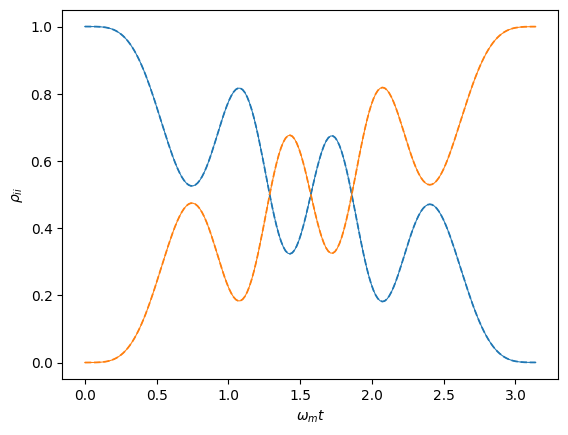

In [5]:
fig, ax = plt.subplots(1, 1)
ax.plot(np.array(ts_SE), np.abs(np.array(ys_SE[0, :, 0]))**2, linewidth=0.75)
ax.plot(np.array(ts_SE), np.abs(np.array(ys_SE[0, :, 1]))**2, linewidth=0.75)
ax.plot(np.array(sol_OBE.t), np.real(np.array(sol_OBE.rho[0, 0])), '--', color='C0', linewidth=1.25)
ax.plot(np.array(sol_OBE.t), np.real(np.array(sol_OBE.rho[1, 1])), '--', color='C1', linewidth=1.25)
ax.set_xlabel('$\omega_m t$')
ax.set_ylabel('$\\rho_{ii}$')

### Reproduce Fig. 2

This involves scanning over $\Delta_0$ and $\Omega_0$.  This takes a long time, only because there is a fair amount of overhead in regenerating the optical Bloch equations on every iteration.

In [6]:
omegam = 1.
Delta0s = np.arange(0.25, 25.1, 0.25)
Omega0s = np.arange(0.25, 25.1, 0.25)

DELTA0S, OMEGA0S = np.meshgrid(Delta0s, Omega0s)

# 2-state OBE without decay, state = [rho_00, Re(rho_01), Im(rho_01), Delta0, Omega0]
# Delta0/Omega0 as frozen state dims → single function object → JIT compiles once,
# cache hit on every subsequent call with same shape.
def rhs_nodecay(t, y):
    rho_00, rho_01_re, rho_01_im, D0, O0 = y[0], y[1], y[2], y[3], y[4]
    Delta = D0 * jnp.cos(omegam * t)
    Omega = O0 * jnp.sin(omegam * t)
    rho_11 = 1. - rho_00
    return jnp.array([
        -Omega * rho_01_im,
        Delta  * rho_01_im,
        -Delta * rho_01_re - 0.5 * Omega * (rho_11 - rho_00),
        0., 0.
    ])

# Warm-up: triggers the one-time JIT compilation
_y0_warm = jnp.array([[1., 0., 0., Delta0s[0], Omega0s[0]]])
solve_ivp_dense(rhs_nodecay, [0., np.pi], _y0_warm, n_points=2)

# Loop — each call reuses the compiled kernel (same func + same shape)
it = np.nditer([DELTA0S, OMEGA0S, None])
for (Delta0, Omega0, rhogg) in it:
    y0 = jnp.array([[1., 0., 0., float(Delta0), float(Omega0)]])
    _, ys = solve_ivp_dense(rhs_nodecay, [0., np.pi], y0, n_points=2)
    rhogg[...] = float(ys[0, -1, 0])

RHOGG = it.operands[2]

Plot it up:

<>:10: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:11: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:10: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:11: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
/tmp/ipykernel_37446/3950664517.py:10: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ax.set_xlabel('$\Delta_0/\omega_m$')
/tmp/ipykernel_37446/3950664517.py:11: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw

Text(0, 0.5, '$\\Omega_0/\\omega_m$')

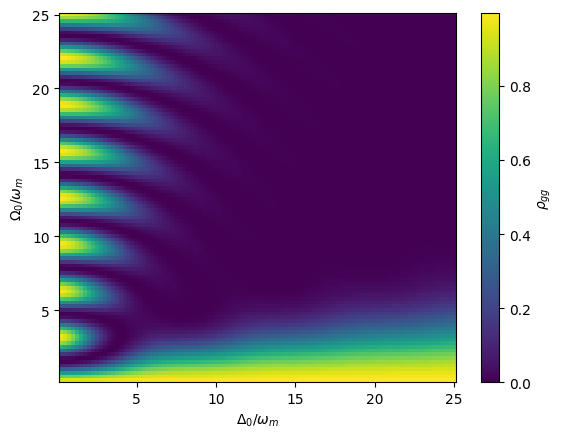

In [7]:
dDelta0 = np.mean(np.diff(Delta0s))
dOmega0 = np.mean(np.diff(Omega0s))
fig, ax = plt.subplots(1, 1)
im = ax.imshow(RHOGG, origin='lower',
               extent=(np.amin(Delta0s)-dDelta0/2, np.amax(Delta0s)+dDelta0/2,
                       np.amin(Omega0s)-dOmega0/2, np.amax(Omega0s)+dOmega0/2),
               aspect='auto')
ax_cbar = plt.colorbar(im)
ax_cbar.set_label('$\\rho_{gg}$')
ax.set_xlabel('$\Delta_0/\omega_m$')
ax.set_ylabel('$\Omega_0/\omega_m$')

### Add in damping

These two cells are exactly the same as above, except the user must now specify $\omega_m/\Gamma$ ($\Gamma=1$) and we merely comment out the line that eliminate the damping part of the OBEs.

In [8]:
omegam = 2
Delta0s = np.arange(0.25, 25.1, 0.25)
Omega0s = np.arange(0.25, 25.1, 0.25)

DELTA0S, OMEGA0S = np.meshgrid(Delta0s, Omega0s)

# 2-state OBE WITH decay (gamma=1)
def rhs_decay(t, y):
    rho_00, rho_01_re, rho_01_im, D0, O0 = y[0], y[1], y[2], y[3], y[4]
    Delta = D0 * jnp.cos(omegam * t)
    Omega = O0 * jnp.sin(omegam * t)
    rho_11 = 1. - rho_00
    return jnp.array([
        -Omega * rho_01_im + rho_11,
        Delta  * rho_01_im - 0.5 * rho_01_re,
        -Delta * rho_01_re - 0.5 * Omega * (rho_11 - rho_00) - 0.5 * rho_01_im,
        0., 0.
    ])

# Warm-up: one-time JIT compilation
_y0_warm = jnp.array([[1., 0., 0., omegam*Delta0s[0], omegam*Omega0s[0]]])
solve_ivp_dense(rhs_decay, [0., np.pi/omegam], _y0_warm, n_points=2)

it = np.nditer([DELTA0S, OMEGA0S, None])
for (Delta0, Omega0, rhogg) in it:
    y0 = jnp.array([[1., 0., 0., omegam*float(Delta0), omegam*float(Omega0)]])
    _, ys = solve_ivp_dense(rhs_decay, [0., np.pi/omegam], y0, n_points=2)
    rhogg[...] = float(ys[0, -1, 0])

RHOGG = it.operands[2]

Plot it up:

<>:10: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:11: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
<>:10: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:11: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw string is also an option.
/tmp/ipykernel_37446/4220429953.py:10: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ax.set_xlabel('$\Delta_0/\omega_m$')
/tmp/ipykernel_37446/4220429953.py:11: SyntaxWarning: "\O" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\O"? A raw

Text(0, 0.5, '$\\Omega_0/\\omega_m$')

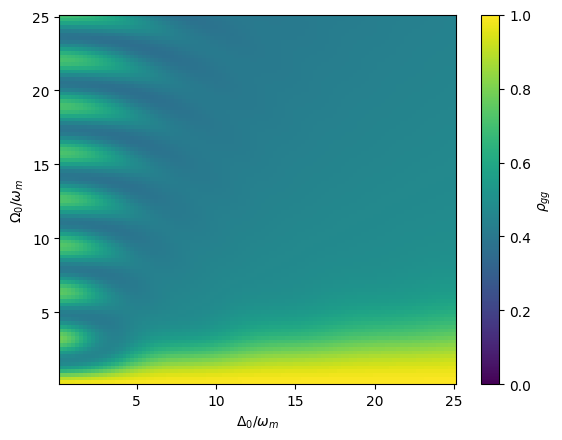

In [9]:
dDelta0 = np.mean(np.diff(Delta0s))
dOmega0 = np.mean(np.diff(Omega0s))
fig, ax = plt.subplots(1, 1)
im = ax.imshow(RHOGG, origin='lower',
               extent=(np.amin(Delta0s)-dDelta0/2, np.amax(Delta0s)+dDelta0/2,
                       np.amin(Omega0s)-dOmega0/2, np.amax(Omega0s)+dOmega0/2),
               aspect='auto', clim=(0, 1))
ax_cbar = plt.colorbar(im)
ax_cbar.set_label('$\\rho_{gg}$')
ax.set_xlabel('$\Delta_0/\omega_m$')
ax.set_ylabel('$\Omega_0/\omega_m$')